<div style="display:flex; justify-content:space-between; align-items:flex-start">

<div>
<span style="color:#3D0814; font-size:35px; font-weight:bold">
Modelo Riesgo Crediticio
</span>

<br>

<span style="color:#9A9B73; font-size:16px">
Erick Chicaiza · Credit Risk Model
</span>
</div>

<div style="font-weight:bold; color:#3D0814; font-size:18px">
ECH
</div>

</div>

<hr>

> Construcción de un modelo de clasificación para predecir la probabilidad de impago utilizando el dataset previamente limpio.

# <span style="color: #3D0814">0. Importación de librerías</span>

---

> Estas son las librerías necesarias para el entrenamiento del modelo, escalado de variables y evaluación de métricas.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import roc_curve, roc_auc_score 

# <span style="color: #3D0814">1. Carga del Dataset limpio</span>

---

> Se carga el dataset previamente procesado en la etapa de limpieza de datos.

In [2]:
df = pd.read_csv("../df/credit_risk_clean.csv") 
df.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,rate_of_interest_missing,Interest_rate_spread_missing,Upfront_charges_missing
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,3.99,...,25-34,to_inst,98.728814,south,direct,1,45.0,1,1,1
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,3.99,...,55-64,to_inst,75.135870,North,direct,1,39.0,1,1,1
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,35-44,to_inst,80.019685,south,direct,0,46.0,0,0,0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,45-54,not_inst,69.376900,North,direct,0,42.0,0,0,1
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,25-34,not_inst,91.886544,North,direct,0,39.0,0,0,0


# <span style="color: #3D0814">2. Codificación de variables categóricas</span>

---

> Se transforman a formato numérico utilizando one-hot encoding para permitir su uso en el modelo.

In [3]:
df = pd.get_dummies(df, drop_first=True)
df = df.fillna(0) 
df.corr()["Status"].abs().sort_values(ascending=False).head(20)

Interest_rate_spread_missing         1.000000
Status                               1.000000
rate_of_interest_missing             0.996242
Upfront_charges_missing              0.942964
credit_type_EQUI                     0.588503
lump_sum_payment_not_lpsm            0.186658
Neg_ammortization_not_neg            0.158488
co-applicant_credit_type_EXP         0.140678
credit_type_CRIF                     0.123013
credit_type_EXP                      0.121361
submission_of_application_to_inst    0.118957
property_value                       0.109444
LTV                                  0.094579
Upfront_charges                      0.094547
dtir1                                0.093791
loan_type_type2                      0.080307
business_or_commercial_nob/c         0.080307
Gender_Joint                         0.078381
Gender_Sex Not Available             0.052710
Interest_rate_spread                 0.052020
Name: Status, dtype: float64

# <span style="color: #3D0814">3. Eliminación de variables con fuga de información</span>

---

> Se eliminan variables altamente correlacionadas con el target que pueden generar data leakage y resultados irreales en el modelo.

In [4]:
df = df.drop(columns=[ 
    "rate_of_interest_missing", 
    "Interest_rate_spread_missing", 
    "Upfront_charges_missing" 
])

# <span style="color: #3D0814">4. Variables predictoras y objetivo</span>

---

> Se separa la variable objetivo Status del resto de variables predictoras.

In [5]:
X = df.drop("Status", axis=1)
y = df["Status"]

# <span style="color: #3D0814">5. División Train / Test</span>

---

> Se divide el df en entrenamiento y prueba para evaluar correctamente el desempeño del modelo.

In [6]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,
    test_size=0.2, 
    random_state=42 
)

# <span style="color: #3D0814">6. Escalado de variables</span>

---

> Se aplica StandardScaler para normalizar las variables numéricas y mejorar la convergencia del modelo.

In [7]:
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

# <span style="color: #3D0814">7. Entrenamiento del modelo</span>

---

> Logistic Regression con balanceo de clases para manejar el desbalance del dataset.

In [8]:
model = LogisticRegression(max_iter=2000, class_weight="balanced") 
model.fit(X_train, y_train) 
y_pred = model.predict(X_test) 
accuracy_score(y_test, y_pred) 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     22250
           1       0.64      0.70      0.67      6927

    accuracy                           0.83     29177
   macro avg       0.77      0.79      0.78     29177
weighted avg       0.84      0.83      0.84     29177



# <span style="color: #3D0814">8. Matriz de confusión</span>

---

> Se evalúa el desempeño del modelo mediante la matriz de confusión.

In [9]:
confusion_matrix(y_test, y_pred)

array([[19485,  2765],
       [ 2082,  4845]])

# <span style="color: #3D0814">9. ROC y AUC</span>

---

> Calculo de la probabilidad default, se genera la curva ROC para evaluar la capacidad de discriminación del modelo.

In [10]:
y_prob = model.predict_proba(X_test)[:,1] 
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
auc = roc_auc_score(y_test, y_prob) 
auc

0.8608470615714765

# <span style="color: #3D0814">10. Visualización curva ROC</span>

---

> La curva ROC permite evaluar el rendimiento del modelo en distintos umbrales de decisión, mientras que el AUC resume la capacidad del modelo para distinguir entre clientes con y sin riesgo de impago.

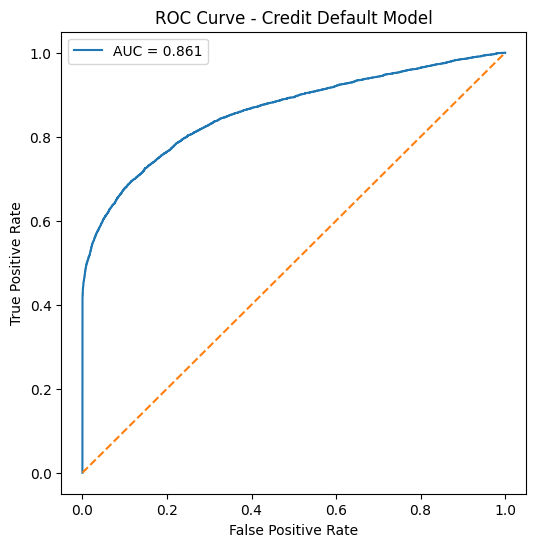

In [11]:
plt.figure(figsize=(6,6)) 
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}") 
plt.plot([0,1],[0,1], linestyle="--") 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title("ROC Curve - Credit Default Model") 
plt.legend() 
plt.show()